In [2]:
!git clone https://github.com/beckhamtoh/CS3244-Gun-Violence.git
%cd CS3244-Gun-Violence

Cloning into 'CS3244-Gun-Violence'...
remote: Enumerating objects: 81, done.
remote: Counting objects: 100% (81/81), done.
remote: Compressing objects: 100% (65/65), done.
remote: Total 81 (delta 28), reused 44 (delta 7), pack-reused 0 (from 0)
Receiving objects: 100% (81/81), 3.17 MiB | 6.64 MiB/s, done.
Resolving deltas: 100% (28/28), done.
/content/CS3244-Gun-Violence


Cloning into 'CS3244-Gun-Violence'...
remote: Enumerating objects: 76, done.
remote: Counting objects: 100% (76/76), done.
remote: Compressing objects: 100% (61/61), done.
remote: Total 76 (delta 26), reused 40 (delta 6), pack-reused 0 (from 0)
Receiving objects: 100% (76/76), 2.24 MiB | 22.07 MiB/s, done.
Resolving deltas: 100% (26/26), done.
/content/CS3244-Gun-Violence/CS3244-Gun-Violence/CS3244-Gun-Violence
Best K: 3 silhouette: 0.185


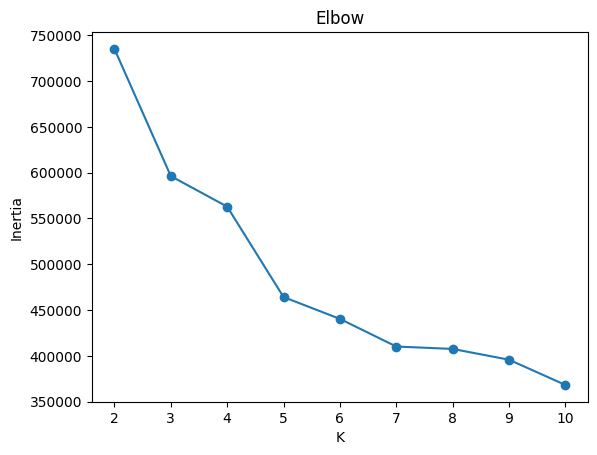

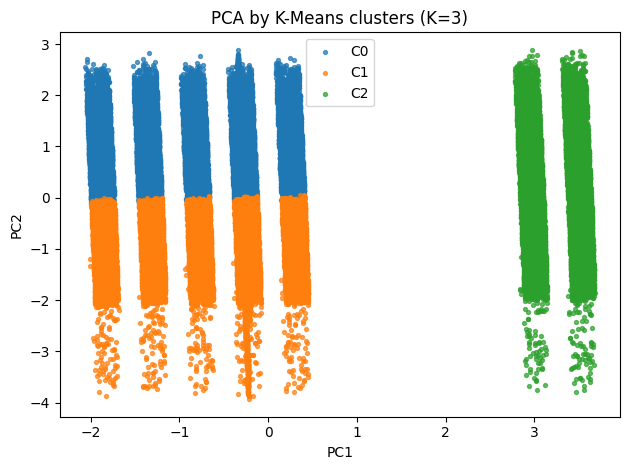

/tmp/ipython-input-512392310.py:110: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  tab = (prof.pivot_table(index="cluster", columns=col, values="Age", aggfunc="size", fill_value=0)


,"(Age, count)","(Age, mean)","(Age, median)","(Police involvement, count)","(Police involvement, mean)","(Police involvement, median)",Race=Asian/Pacific Islander,Race=Black,Race=Hispanic,Race=Native American/Native Alaskan,...,Reason=Undetermined,AgeBucket=<=17,AgeBucket=18-25,AgeBucket=26-35,AgeBucket=36-45,AgeBucket=46-55,AgeBucket=56-65,AgeBucket=66+,Sex=Female,Sex=Male
cluster,,,,,,,,,,,,,,,,,,,,,
0,44549,60.46,59.0,44553,0.00,0.0,0.009,0.035,0.028,0.005,...,0.007,0.000,0.000,0.000,0.136,0.273,0.262,0.329,0.157,0.843
1,43868,29.08,28.0,43881,0.03,0.0,0.018,0.431,0.151,0.013,...,0.010,0.054,0.347,0.386,0.159,0.047,0.006,0.000,0.129,0.871
2,12363,44.64,42.0,12364,0.01,0.0,0.013,0.231,0.091,0.010,...,0.006,0.026,0.171,0.198,0.152,0.156,0.132,0.164,0.144,0.856


In [4]:
# import libraries
import pandas as pd, numpy as np
from pathlib import Path
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# import dataset
file_path = "../data/raw/Guns incident Data.csv"
df = pd.read_csv(file_path)

# basic cleaning (can remove and import cleaned dataset later)
df = df.replace({"NA": np.nan}) # replace NA
df["Age"] = pd.to_numeric(df["Age"], errors = "coerce")
df["Police involvement"] = pd.to_numeric(df["Police involvement"], errors="coerce")
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

# columns to keep
useful_cols = ["Date", "Reason", "Education", "Sex", "Age", "Race", "Place of incident", "Police involvement"]
df_copy = df[useful_cols].copy()

# --- Feature Engineering ---
bins = [-np.inf, 17, 25, 35, 45, 55, 65, np.inf]
labels = ["<=17","18-25","26-35","36-45","46-55","56-65","66+"]
df_copy["AgeBucket"] = pd.cut(df_copy["Age"], bins=bins, labels=labels)  # <-- use AgeBucket consistently

df_copy["Month"]   = df_copy["Date"].dt.month
df_copy["Weekday"] = df_copy["Date"].dt.weekday
df_copy["IsWeekend"] = df_copy["Weekday"].isin([5,6]).astype("float")

def combine_small_categories(s: pd.Series, min_count=700, other_label="Other"):
    counts = s.value_counts(dropna=True)
    keep = counts[counts >= min_count].index
    return s.where(s.isin(keep), other_label)

for col in ["Race","Education","Place of incident","Reason"]:
    df_copy[col] = combine_small_categories(df_copy[col], min_count=700)

# final feature set (match names exactly)
cat_features = ["Race","Education","Place of incident","Reason","AgeBucket","Sex"]
num_features = ["Age","Month","Weekday","IsWeekend","Police involvement"]

df_cluster = df_copy[cat_features + num_features].copy()

# --- Preprocess ---
cat_pipeline = Pipeline([
    ("imp", SimpleImputer(strategy="most_frequent")),
    ("oh" , OneHotEncoder(handle_unknown="ignore", sparse_output=False))  # if older sklearn, use sparse=False
])

num_pipeline = Pipeline([
    ("imp", SimpleImputer(strategy="median")),
    ("sc" , StandardScaler())
])

# Use the SAME variable names you defined above
pre = ColumnTransformer([
    ("cat", cat_pipeline, cat_features),
    ("num", num_pipeline, num_features)
], remainder="drop")

# --- Pick K (silhouette + elbow) and fit K-Means ---
df_pre = pre.fit_transform(df_cluster)

best_k, best_score, scores = None, -1, {}
for k in range(2, 11):
    km = KMeans(n_clusters=k, n_init="auto", random_state=3244)
    labels = km.fit_predict(df_pre)
    s = silhouette_score(df_pre, labels)
    scores[k] = s
    if s > best_score:
        best_k, best_score = k, s
print("Best K:", best_k, "silhouette:", round(best_score,3))

inertias = []
for k in range(2, 11):
    inertias.append(KMeans(n_clusters=k, n_init="auto", random_state=3244).fit(df_pre).inertia_)
plt.plot(range(2,11), inertias, marker="o"); plt.title("Elbow"); plt.xlabel("K"); plt.ylabel("Inertia"); plt.show()

kmeans = KMeans(n_clusters=best_k, n_init="auto", random_state=3244)
labels = kmeans.fit_predict(df_pre)

# 2D PCA plot
pca = PCA(n_components=2, random_state=3244)
X_2d = pca.fit_transform(df_pre)
plot_df = pd.DataFrame({"PC1":X_2d[:,0], "PC2":X_2d[:,1], "cluster":labels})

for c in sorted(plot_df.cluster.unique()):
    sub = plot_df[plot_df.cluster==c]
    plt.scatter(sub.PC1, sub.PC2, s=8, alpha=0.7, label=f"C{c}")
plt.legend(); plt.title(f"PCA by K-Means clusters (K={best_k})")
plt.xlabel("PC1"); plt.ylabel("PC2"); plt.tight_layout(); plt.show()

# --- Cluster Profile Table ---
prof = df_copy.copy()
prof["cluster"] = labels

num_summary = prof.groupby("cluster")[["Age","Police involvement"]].agg(["count","mean","median"]).round(2)

def prop_table(col):
    tab = (prof.pivot_table(index="cluster", columns=col, values="Age", aggfunc="size", fill_value=0)
              .apply(lambda r: r/r.sum(), axis=1))
    tab.columns = [f"{col}={c}" for c in tab.columns]
    return tab.round(3)

cat_summary = pd.concat([prop_table(c) for c in ["Race","Education","Place of incident","Reason","AgeBucket","Sex"]], axis=1)

cluster_profile = pd.concat([num_summary, cat_summary], axis=1).sort_index()
cluster_profile.head()



In [3]:
!ls

'academic articles'   data	  README.md   requirements.txt
 config.py	      notebooks   reports     src
